In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/wallet_features_processed.csv")

In [3]:
df.shape

(9540, 19)

In [4]:
df.head()

,address,fraud_flag,has_transaction_activity,has_token_activity,log_total_transactions,log_unique_receivers,log_unique_senders,log_total_eth_sent,log_total_eth_received,log_avg_eth_sent,log_avg_eth_received,log_wallet_lifetime_days,transactions_per_active_day,avg_gas_limit,avg_gas_price,log_total_token_transfers,log_unique_token_receivers,log_token_activity_lifetime_days,token_transfers_per_active_day
0,0x8aa31705fa6f0a7801e8d881ba4c47de23d2652a,0,1,0,3.465736,2.708050,2.302585,4.163209,4.163316,1.389592,1.991762,6.966967,1.550000,21100.047619,1.560022e+10,0.0,0.0,0.0,0.0
1,0x4911487b52134454384d33875dfd7d22e2c5d783,0,1,0,3.828641,3.091042,2.079442,4.271632,4.271761,1.437662,1.404046,4.700480,2.500000,21001.000000,2.000000e+10,0.0,0.0,0.0,0.0
2,0x2497ecd2ec7dd88e41dff727c0b6f14a85956993,0,1,0,4.477337,3.784190,1.945910,2.011109,2.014181,0.140199,0.137676,4.762174,2.175000,21000.000000,2.545315e+10,0.0,0.0,0.0,0.0
3,0xc4fbde4c51b306e3f3e1ae55a5a888be58fcfd00,0,1,0,3.465736,2.708050,2.484907,2.209192,2.209811,0.355403,0.516509,6.900731,2.066667,21221.105263,1.004902e+10,0.0,0.0,0.0,0.0
4,0xbb90125091fd7c7953fb98b59f6ce75e2500e5db,1,1,0,3.401197,2.772589,2.564949,3.438003,3.336799,1.101380,1.077655,1.791759,5.800000,21000.000000,1.106667e+10,0.0,0.0,0.0,0.0


In [5]:
X = df.drop(columns=["address", "fraud_flag"])
y = df["fraud_flag"]

In [6]:
X.shape

(9540, 17)

In [7]:
y.value_counts()

fraud_flag
0    7637
1    1903
Name: count, dtype: int64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (7632, 17)
Testing: (1908, 17)


In [10]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
fraud_flag
0    0.800577
1    0.199423
Name: proportion, dtype: float64

Testing distribution:
fraud_flag
0    0.800314
1    0.199686
Name: proportion, dtype: float64


In [11]:
def evaluate_model(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }

    return results

In [12]:
dummy_model = DummyClassifier(
    strategy="prior",
    random_state=42
)

dummy_model.fit(X_train, y_train)

DummyClassifier(random_state=42)

In [13]:
dummy_results = evaluate_model(
    "Dummy Baseline",
    dummy_model,
    X_test,
    y_test
)

dummy_results

/Users/draekon/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'Model': 'Dummy Baseline',
 'Accuracy': 0.800314465408805,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': np.float64(0.5),
 'PR_AUC': np.float64(0.19968553459119498)}

In [14]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [15]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [16]:
logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.9140461215932913,
 'Precision': 0.8511326860841424,
 'Recall': 0.6902887139107612,
 'F1': 0.7623188405797101,
 'ROC_AUC': np.float64(0.9498287173828222),
 'PR_AUC': np.float64(0.8499206072551485)}

In [17]:
logistic_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [18]:
logistic_balanced.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [19]:
logistic_balanced_results = evaluate_model(
    "Logistic Regression Balanced",
    logistic_balanced,
    X_test,
    y_test
)

logistic_balanced_results

{'Model': 'Logistic Regression Balanced',
 'Accuracy': 0.8763102725366876,
 'Precision': 0.6278659611992945,
 'Recall': 0.9343832020997376,
 'F1': 0.7510548523206751,
 'ROC_AUC': np.float64(0.9532096798312784),
 'PR_AUC': np.float64(0.8212267152253773)}

In [20]:
results_df = pd.DataFrame([
    dummy_results,
    logistic_results,
    logistic_balanced_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.800314,0.000000,0.000000,0.000000,0.500000,0.199686
1,Logistic Regression,0.914046,0.851133,0.690289,0.762319,0.949829,0.849921
2,Logistic Regression Balanced,0.876310,0.627866,0.934383,0.751055,0.953210,0.821227


In [21]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [22]:
rf_results = evaluate_model(
    "Random Forest",
    random_forest,
    X_test,
    y_test
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.9685534591194969,
 'Precision': 0.952112676056338,
 'Recall': 0.8871391076115486,
 'F1': 0.9184782608695652,
 'ROC_AUC': np.float64(0.9889504234367561),
 'PR_AUC': np.float64(0.9719049327037144)}

In [23]:
random_forest_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [24]:
rf_balanced_results = evaluate_model(
    "Random Forest Balanced",
    random_forest_balanced,
    X_test,
    y_test
)

rf_balanced_results

{'Model': 'Random Forest Balanced',
 'Accuracy': 0.9696016771488469,
 'Precision': 0.9601139601139601,
 'Recall': 0.884514435695538,
 'F1': 0.9207650273224044,
 'ROC_AUC': np.float64(0.9881752256409991),
 'PR_AUC': np.float64(0.9716079469279497)}

In [25]:
results_df = pd.DataFrame([
    dummy_results,
    logistic_results,
    logistic_balanced_results,
    rf_results,
    rf_balanced_results
])

results_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,Random Forest Balanced,0.969602,0.960114,0.884514,0.920765,0.988175,0.971608
3,Random Forest,0.968553,0.952113,0.887139,0.918478,0.988950,0.971905
1,Logistic Regression,0.914046,0.851133,0.690289,0.762319,0.949829,0.849921
2,Logistic Regression Balanced,0.876310,0.627866,0.934383,0.751055,0.953210,0.821227
0,Dummy Baseline,0.800314,0.000000,0.000000,0.000000,0.500000,0.199686


In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [28]:
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [29]:
rf_cv = cross_validate(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [30]:
pd.DataFrame(rf_cv).filter(like="test_").mean()

test_precision    0.948271
test_recall       0.842327
test_f1           0.892052
test_roc_auc      0.988052
test_pr_auc       0.964505
dtype: float64

In [31]:
rf_balanced_cv = cross_validate(
    random_forest_balanced,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [32]:
pd.DataFrame(rf_balanced_cv).filter(like="test_").mean()

test_precision    0.951873
test_recall       0.828531
test_f1           0.885790
test_roc_auc      0.987913
test_pr_auc       0.962882
dtype: float64

In [33]:
pd.DataFrame(rf_cv).filter(like="test_").std()

test_precision    0.006965
test_recall       0.020519
test_f1           0.011798
test_roc_auc      0.003411
test_pr_auc       0.004780
dtype: float64

In [34]:
pd.DataFrame(rf_balanced_cv).filter(like="test_").std()

test_precision    0.013072
test_recall       0.019317
test_f1           0.011764
test_roc_auc      0.002701
test_pr_auc       0.004042
dtype: float64

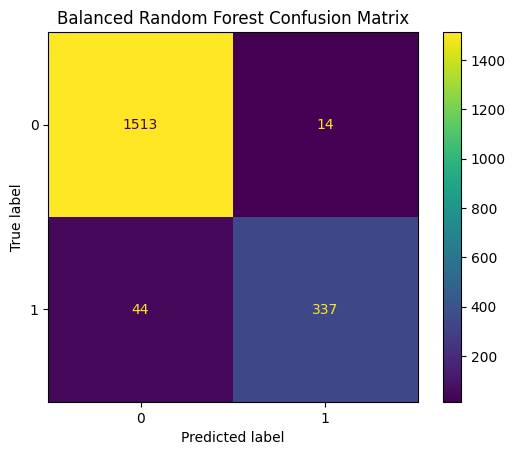

In [35]:
ConfusionMatrixDisplay.from_estimator(
    random_forest_balanced,
    X_test,
    y_test
)

plt.title("Balanced Random Forest Confusion Matrix")
plt.show()

In [36]:
rf_cv_df = pd.DataFrame(rf_cv)

rf_cv_df.filter(like="test_").mean()

test_precision    0.948271
test_recall       0.842327
test_f1           0.892052
test_roc_auc      0.988052
test_pr_auc       0.964505
dtype: float64

In [37]:
rf_cv_df.filter(like="test_").std()

test_precision    0.006965
test_recall       0.020519
test_f1           0.011798
test_roc_auc      0.003411
test_pr_auc       0.004780
dtype: float64

In [38]:
rf_balanced_cv_df = pd.DataFrame(rf_balanced_cv)

rf_balanced_cv_df.filter(like="test_").mean()

test_precision    0.951873
test_recall       0.828531
test_f1           0.885790
test_roc_auc      0.987913
test_pr_auc       0.962882
dtype: float64

In [39]:
rf_balanced_cv_df.filter(like="test_").std()

test_precision    0.013072
test_recall       0.019317
test_f1           0.011764
test_roc_auc      0.002701
test_pr_auc       0.004042
dtype: float64

In [40]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [41]:
gradient_boosting = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    random_state=42
)

In [42]:
gradient_boosting.fit(X_train, y_train)

HistGradientBoostingClassifier(max_iter=200, random_state=42)

In [43]:
gb_results = evaluate_model(
    "Gradient Boosting",
    gradient_boosting,
    X_test,
    y_test
)

gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.9716981132075472,
 'Precision': 0.9455040871934605,
 'Recall': 0.910761154855643,
 'F1': 0.9278074866310161,
 'ROC_AUC': np.float64(0.9918475318286589),
 'PR_AUC': np.float64(0.980207927727559)}

In [44]:
gb_cv = cross_validate(
    gradient_boosting,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [45]:
gb_cv_df = pd.DataFrame(gb_cv)

gb_cv_df.filter(like="test_").mean()

test_precision    0.945949
test_recall       0.890921
test_f1           0.917352
test_roc_auc      0.992183
test_pr_auc       0.976342
dtype: float64

In [46]:
gb_cv_df.filter(like="test_").std()

test_precision    0.014250
test_recall       0.023933
test_f1           0.010699
test_roc_auc      0.001704
test_pr_auc       0.004761
dtype: float64

In [49]:
results_df = pd.DataFrame([
    dummy_results,
    logistic_results,
    logistic_balanced_results,
    rf_results,
    rf_balanced_results,
    gb_results
])

results_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
5,Gradient Boosting,0.971698,0.945504,0.910761,0.927807,0.991848,0.980208
4,Random Forest Balanced,0.969602,0.960114,0.884514,0.920765,0.988175,0.971608
3,Random Forest,0.968553,0.952113,0.887139,0.918478,0.988950,0.971905
1,Logistic Regression,0.914046,0.851133,0.690289,0.762319,0.949829,0.849921
2,Logistic Regression Balanced,0.876310,0.627866,0.934383,0.751055,0.953210,0.821227
0,Dummy Baseline,0.800314,0.000000,0.000000,0.000000,0.500000,0.199686


In [50]:
from sklearn.model_selection import RandomizedSearchCV

In [51]:
param_grid = {
    "learning_rate": [0.03, 0.05, 0.08, 0.10, 0.15],
    "max_iter": [100, 200, 300, 500],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0]
}

In [52]:
gb_search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=HistGradientBoostingClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'l2_regularization': [0.0, 0.1, 1.0,
                                                              5.0],
                                        'learning_rate': [0.03, 0.05, 0.08, 0.1,
                                                          0.15],
                                        'max_depth': [None, 5, 10],
                                        'max_iter': [100, 200, 300, 500],
                                        'max_leaf_nodes': [15, 31, 63],
                                        'min_samples_leaf': [10, 20, 30, 50]},
                   random_state=42, scoring='average_precision', verbose=1)

In [53]:
gb_search.best_params_

{'min_samples_leaf': 10,
 'max_leaf_nodes': 63,
 'max_iter': 300,
 'max_depth': 5,
 'learning_rate': 0.08,
 'l2_regularization': 0.0}

In [54]:
gb_search.best_score_

np.float64(0.9773132474478586)

In [55]:
best_gb = gb_search.best_estimator_

In [56]:
best_gb_cv = cross_validate(
    best_gb,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

best_gb_cv_df = pd.DataFrame(best_gb_cv)

In [57]:
best_gb_cv_df.filter(like="test_").mean()

test_precision    0.953696
test_recall       0.886984
test_f1           0.918947
test_roc_auc      0.992059
test_pr_auc       0.977313
dtype: float64

In [58]:
best_gb_cv_df.filter(like="test_").std()

test_precision    0.013199
test_recall       0.017546
test_f1           0.006143
test_roc_auc      0.001201
test_pr_auc       0.002458
dtype: float64

In [59]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

In [60]:
oof_prob = cross_val_predict(
    best_gb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [61]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    oof_prob
)

In [62]:
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1])
)

In [63]:
f1_scores = np.nan_to_num(f1_scores)

In [64]:
best_threshold_index = np.argmax(f1_scores)

best_threshold = thresholds[best_threshold_index]

best_threshold

np.float64(0.3002491667684036)

In [65]:
print("Threshold:", best_threshold)
print("Precision:", precision[best_threshold_index])
print("Recall:", recall[best_threshold_index])
print("F1:", f1_scores[best_threshold_index])

Threshold: 0.3002491667684036
Precision: 0.9239842726081258
Recall: 0.926412614980289
F1: 0.9251968503937008


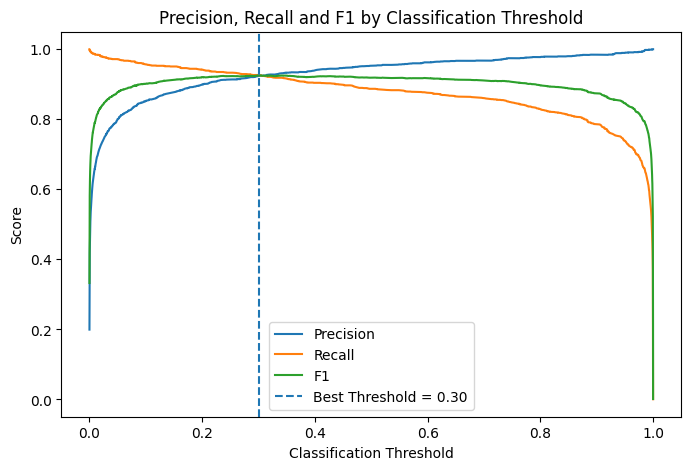

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.plot(
    thresholds,
    f1_scores,
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 by Classification Threshold")
plt.legend()
plt.show()

In [67]:
best_gb.fit(X_train, y_train)

HistGradientBoostingClassifier(learning_rate=0.08, max_depth=5, max_iter=300,
                               max_leaf_nodes=63, min_samples_leaf=10,
                               random_state=42)

In [68]:
test_prob = best_gb.predict_proba(X_test)[:, 1]

In [69]:
test_pred_threshold = (
    test_prob >= best_threshold
).astype(int)

In [70]:
threshold_results = {
    "Accuracy": accuracy_score(
        y_test,
        test_pred_threshold
    ),
    "Precision": precision_score(
        y_test,
        test_pred_threshold
    ),
    "Recall": recall_score(
        y_test,
        test_pred_threshold
    ),
    "F1": f1_score(
        y_test,
        test_pred_threshold
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        test_prob
    )
}

threshold_results

{'Accuracy': 0.9680293501048218,
 'Precision': 0.9166666666666666,
 'Recall': 0.9238845144356955,
 'F1': 0.9202614379084967,
 'ROC_AUC': np.float64(0.9906443423452226),
 'PR_AUC': np.float64(0.9779591536703502)}

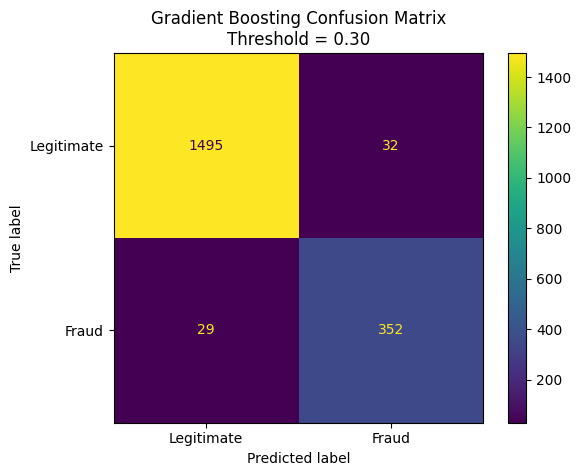

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred_threshold,
    display_labels=["Legitimate", "Fraud"]
)

plt.title(
    f"Gradient Boosting Confusion Matrix\nThreshold = {best_threshold:.2f}"
)

plt.show()

In [72]:
from sklearn.inspection import permutation_importance

In [73]:
perm_importance = permutation_importance(
    best_gb,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [74]:
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
})

In [75]:
importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df

,feature,importance,std
0,avg_gas_price,0.084238,0.005719
1,log_unique_senders,0.076764,0.006744
2,log_total_transactions,0.036973,0.004715
3,log_wallet_lifetime_days,0.033613,0.003925
4,log_total_eth_received,0.026324,0.002211
5,has_token_activity,0.021420,0.001899
6,avg_gas_limit,0.014090,0.002206
7,log_avg_eth_received,0.010715,0.001784
8,log_avg_eth_sent,0.008095,0.001069
9,transactions_per_active_day,0.006493,0.001087


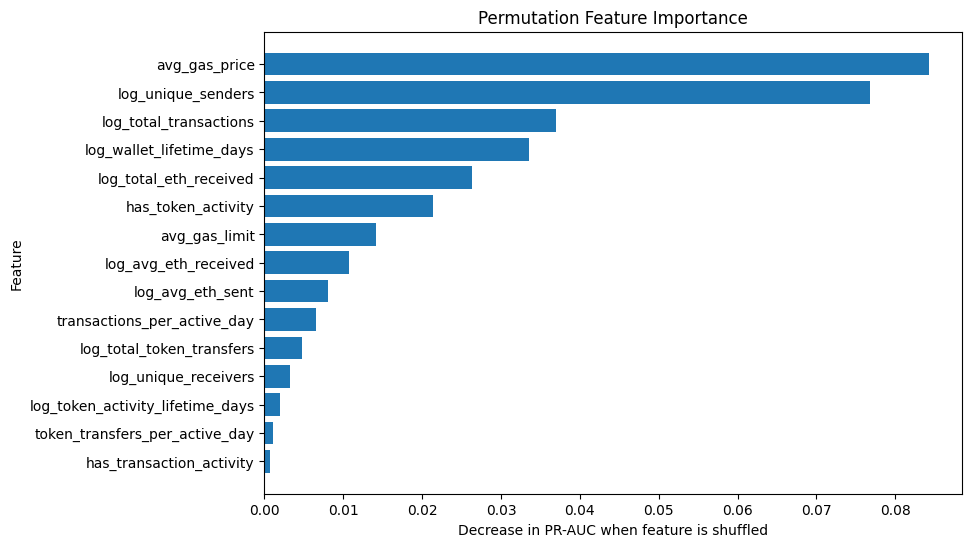

In [76]:
top_features = importance_df.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.show()

In [77]:
results_df = pd.DataFrame([
    dummy_results,
    logistic_results,
    logistic_balanced_results,
    rf_results,
    rf_balanced_results,
    gb_results
])

results_df.to_csv(
    "../data/model_comparison.csv",
    index=False
)

In [78]:
final_results = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting - Threshold Optimized",
    "Accuracy": accuracy_score(y_test, test_pred_threshold),
    "Precision": precision_score(y_test, test_pred_threshold),
    "Recall": recall_score(y_test, test_pred_threshold),
    "F1": f1_score(y_test, test_pred_threshold),
    "ROC_AUC": roc_auc_score(y_test, test_prob),
    "PR_AUC": average_precision_score(y_test, test_prob),
    "Threshold": best_threshold
}])

final_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Threshold
0,Tuned Gradient Boosting - Threshold Optimized,0.968029,0.916667,0.923885,0.920261,0.990644,0.977959,0.300249


In [79]:
final_results.to_csv(
    "../data/final_model_results.csv",
    index=False
)

In [80]:
risk_df = X_test.copy()

risk_df["actual_fraud"] = y_test.values
risk_df["fraud_probability"] = test_prob
risk_df["predicted_fraud"] = test_pred_threshold

In [81]:
risk_df["address"] = df.loc[X_test.index, "address"].values

In [82]:
risk_df["risk_level"] = pd.cut(
    risk_df["fraud_probability"],
    bins=[-0.01, 0.10, 0.30, 0.70, 1.00],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [83]:
risk_df[
    [
        "address",
        "actual_fraud",
        "fraud_probability",
        "predicted_fraud",
        "risk_level"
    ]
].sort_values(
    "fraud_probability",
    ascending=False
).head(20)

,address,actual_fraud,fraud_probability,predicted_fraud,risk_level
5003,0xb9ee29ff43d319c126ed2dbdd74d49a2659ede56,1,0.999999,1,Very High
4868,0x0a10c493bc6f7faecca5be1e82d7fd7fb3774049,1,0.999997,1,Very High
5033,0x0c4762bc7b1af1dc9448a827f53861c118b712de,1,0.999994,1,Very High
8505,0xd0acac843aaab4cef20b322405405e67e90147d1,1,0.999994,1,Very High
4827,0x24f7ea54d9cdb021c0788caab3c1796aa8b2c161,1,0.999993,1,Very High
8188,0x839db3994bef8842c0809ab84996ba839fcac11e,1,0.999993,1,Very High
4972,0x024c344da7208e60356378a252dab771c34be111,1,0.999993,1,Very High
6725,0xb5eb9d18c0413535baf1fa8bd8bf8f6ea7fea47a,1,0.999990,1,Very High
7972,0x606188614094946e0fcd05a0c94d51ff586fb01b,1,0.999989,1,Very High
4745,0x18341b373c795736c09bef6bef09bcecba4d27ff,1,0.999986,1,Very High


In [84]:
risk_df.to_csv(
    "../data/wallet_risk_scores.csv",
    index=False
)

In [85]:
importance_df.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [86]:
test_risk_df = pd.DataFrame({
    "address": df.loc[X_test.index, "address"],
    "actual_fraud": y_test,
    "fraud_probability": test_prob,
    "predicted_fraud": test_pred_threshold
})

In [87]:
test_risk_df["risk_level"] = pd.cut(
    test_risk_df["fraud_probability"],
    bins=[-0.01, 0.10, 0.30, 0.70, 1.00],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [88]:
test_risk_df.head()

,address,actual_fraud,fraud_probability,predicted_fraud,risk_level
7840,0x39686173a2b1eba4ac6132bbcbf8173475cc591d,0,0.000015,0,Low
2507,0x1c91eff83150024d313f8f5032f1e4259159d092,0,0.000045,0,Low
6966,0xc3e2d2e273460abe1974e9d6c580c9283505ed03,0,0.000006,0,Low
1810,0x13403162ef6cf6219441667ae22892c997262611,1,0.999798,1,Very High
1155,0x99c041f0befbb441607e4567d3039e9f55c91d02,0,0.000103,0,Low


In [89]:
test_risk_df["risk_level"].value_counts()

risk_level
Low          1483
Very High     350
Moderate       41
High           34
Name: count, dtype: int64

In [90]:
test_risk_df.to_csv(
    "../data/test_wallet_risk_scores.csv",
    index=False
)

In [91]:
final_model = HistGradientBoostingClassifier(
    min_samples_leaf=10,
    max_leaf_nodes=63,
    max_iter=300,
    max_depth=5,
    learning_rate=0.08,
    l2_regularization=0.0,
    random_state=42
)

In [92]:
final_model.fit(X, y)

HistGradientBoostingClassifier(learning_rate=0.08, max_depth=5, max_iter=300,
                               max_leaf_nodes=63, min_samples_leaf=10,
                               random_state=42)

In [93]:
all_prob = final_model.predict_proba(X)[:, 1]

In [94]:
all_pred = (
    all_prob >= best_threshold
).astype(int)

In [95]:
wallet_scores = df.copy()

wallet_scores["fraud_probability"] = all_prob
wallet_scores["predicted_fraud"] = all_pred

In [96]:
wallet_scores["risk_level"] = pd.cut(
    wallet_scores["fraud_probability"],
    bins=[-0.01, 0.10, 0.30, 0.70, 1.00],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [97]:
wallet_scores.to_csv(
    "../data/wallet_risk_scores.csv",
    index=False
)

In [98]:
risk_df.to_csv(
    "../data/test_wallet_risk_scores.csv",
    index=False
)

In [99]:
final_model = HistGradientBoostingClassifier(
    min_samples_leaf=10,
    max_leaf_nodes=63,
    max_iter=300,
    max_depth=5,
    learning_rate=0.08,
    l2_regularization=0.0,
    random_state=42
)

final_model.fit(X, y)

HistGradientBoostingClassifier(learning_rate=0.08, max_depth=5, max_iter=300,
                               max_leaf_nodes=63, min_samples_leaf=10,
                               random_state=42)

In [100]:
wallet_scores = df.copy()

wallet_scores["fraud_probability"] = all_prob
wallet_scores["predicted_fraud"] = all_pred

wallet_scores["risk_level"] = pd.cut(
    wallet_scores["fraud_probability"],
    bins=[-0.01, 0.10, 0.30, 0.70, 1.00],
    labels=["Low", "Moderate", "High", "Very High"]
)

In [101]:
wallet_scores.to_csv(
    "../data/wallet_risk_scores.csv",
    index=False
)

In [102]:
raw_df = pd.read_csv("../data/wallet_features.csv")

In [103]:
raw_df.shape

(9540, 29)

In [104]:
score_cols = wallet_scores[
    [
        "address",
        "fraud_probability",
        "predicted_fraud",
        "risk_level"
    ]
].copy()

In [105]:
score_cols.head()

,address,fraud_probability,predicted_fraud,risk_level
0,0x8aa31705fa6f0a7801e8d881ba4c47de23d2652a,0.000106,0,Low
1,0x4911487b52134454384d33875dfd7d22e2c5d783,0.000046,0,Low
2,0x2497ecd2ec7dd88e41dff727c0b6f14a85956993,0.000605,0,Low
3,0xc4fbde4c51b306e3f3e1ae55a5a888be58fcfd00,0.007857,0,Low
4,0xbb90125091fd7c7953fb98b59f6ce75e2500e5db,0.998350,1,Very High


In [106]:
dashboard_df = raw_df.merge(
    score_cols,
    on="address",
    how="left"
)

In [107]:
dashboard_df.shape

(9540, 32)

In [108]:
dashboard_df["transactions_per_active_day"] = (
    dashboard_df["transactions_per_active_day"].fillna(0)
)

dashboard_df["token_transfers_per_active_day"] = (
    dashboard_df["token_transfers_per_active_day"].fillna(0)
)

In [109]:
dashboard_df.isna().sum().sum()

np.int64(0)

In [110]:
dashboard_df[
    [
        "address",
        "fraud_flag",
        "fraud_probability",
        "predicted_fraud",
        "risk_level"
    ]
].head()

,address,fraud_flag,fraud_probability,predicted_fraud,risk_level
0,0x8aa31705fa6f0a7801e8d881ba4c47de23d2652a,0,0.000106,0,Low
1,0x4911487b52134454384d33875dfd7d22e2c5d783,0,0.000046,0,Low
2,0x2497ecd2ec7dd88e41dff727c0b6f14a85956993,0,0.000605,0,Low
3,0xc4fbde4c51b306e3f3e1ae55a5a888be58fcfd00,0,0.007857,0,Low
4,0xbb90125091fd7c7953fb98b59f6ce75e2500e5db,1,0.998350,1,Very High


In [111]:
dashboard_df["risk_level"].value_counts()

risk_level
Low          7495
Very High    1864
Moderate      113
High           68
Name: count, dtype: int64

In [112]:
dashboard_df["predicted_fraud"].value_counts()

predicted_fraud
0    7608
1    1932
Name: count, dtype: int64

In [113]:
dashboard_df.to_csv(
    "../data/powerbi_wallet_dashboard.csv",
    index=False
)

In [114]:
importance_df.to_csv(
    "../data/feature_importance.csv",
    index=False
)

In [115]:
final_model_row = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy_score(y_test, test_pred_threshold),
    "Precision": precision_score(y_test, test_pred_threshold),
    "Recall": recall_score(y_test, test_pred_threshold),
    "F1": f1_score(y_test, test_pred_threshold),
    "ROC_AUC": roc_auc_score(y_test, test_prob),
    "PR_AUC": average_precision_score(y_test, test_prob)
}])

In [116]:
model_comparison = pd.concat(
    [results_df, final_model_row],
    ignore_index=True
)

In [117]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Dummy Baseline,0.800314,0.000000,0.000000,0.000000,0.500000,0.199686
1,Logistic Regression,0.914046,0.851133,0.690289,0.762319,0.949829,0.849921
2,Logistic Regression Balanced,0.876310,0.627866,0.934383,0.751055,0.953210,0.821227
3,Random Forest,0.968553,0.952113,0.887139,0.918478,0.988950,0.971905
4,Random Forest Balanced,0.969602,0.960114,0.884514,0.920765,0.988175,0.971608
5,Gradient Boosting,0.971698,0.945504,0.910761,0.927807,0.991848,0.980208
6,Tuned Gradient Boosting,0.968029,0.916667,0.923885,0.920261,0.990644,0.977959


In [118]:
model_comparison.to_csv(
    "../data/model_comparison.csv",
    index=False
)

In [119]:
cm = confusion_matrix(
    y_test,
    test_pred_threshold
)

In [120]:
confusion_df = pd.DataFrame({
    "Actual": [
        "Legitimate",
        "Legitimate",
        "Fraud",
        "Fraud"
    ],
    "Predicted": [
        "Legitimate",
        "Fraud",
        "Legitimate",
        "Fraud"
    ],
    "Count": [
        cm[0, 0],
        cm[0, 1],
        cm[1, 0],
        cm[1, 1]
    ]
})

confusion_df

,Actual,Predicted,Count
0,Legitimate,Legitimate,1495
1,Legitimate,Fraud,32
2,Fraud,Legitimate,29
3,Fraud,Fraud,352


In [121]:
confusion_df.to_csv(
    "../data/confusion_matrix.csv",
    index=False
)

In [1]:
import pandas as pd

wallet_dashboard = pd.read_csv("../data/powerbi_wallet_dashboard.csv")
feature_importance = pd.read_csv("../data/feature_importance.csv")
model_comparison = pd.read_csv("../data/model_comparison.csv")
confusion_matrix = pd.read_csv("../data/confusion_matrix.csv")

with pd.ExcelWriter(
    "../data/web3_powerbi_data.xlsx",
    engine="openpyxl"
) as writer:

    wallet_dashboard.to_excel(
        writer,
        sheet_name="Wallet Dashboard",
        index=False
    )

    feature_importance.to_excel(
        writer,
        sheet_name="Feature Importance",
        index=False
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    confusion_matrix.to_excel(
        writer,
        sheet_name="Confusion Matrix",
        index=False
    )